# MLP path (VMIM on hand-crafted summaries (PDF / PS))
Direct VMIM inference on fixed summary statistics; the MLP "compressor" maps the hand-made PDF/PS features to `t`.

## Setup

In [1]:
import os, glob, subprocess
from pathlib import Path
from IPython.display import Image, display
import pandas as pd, yaml

os.environ['MPLBACKEND'] = 'Agg'                      # headless plotting for the CLI tools
REPO = subprocess.check_output(['git', 'rev-parse', '--show-toplevel']).decode().strip()
os.chdir(REPO)
print('repo:', REPO)

def sh(cmd):
    """Run a shell command, echoing it first; its output streams into the cell."""
    print('$', cmd, flush=True)
    return subprocess.run(cmd, shell=True)

def show(path, width=1000):
    """Display a PNG, or rasterize + display page 1 of a PDF (needs pdftoppm)."""
    p = str(path)
    if p.endswith('.png') and os.path.exists(p):
        display(Image(p, width=width)); return
    if p.endswith('.pdf') and os.path.exists(p):
        prev = p[:-4] + '_preview'
        if os.system(f'pdftoppm -png -r 150 -singlefile "{p}" "{prev}" 2>/dev/null') == 0 \
           and os.path.exists(prev + '.png'):
            display(Image(prev + '.png', width=width)); return
    print('figure not found:', p)

repo: /obs/ddehiwalage-don/21cm/sbi_project


## Config

In [2]:
# ---- path identity -------------------------------------------------------
PATHDIR = 'mlp'                       # figures -> notebooks/figs_<PATHDIR>/
CONFIG  = [
    'configs_seeds/mlp_/arm_mlp_pdf_ps.yaml',
#    'configs_seeds/mlp_/arm_mlp_ps.yaml'
]   # arm config(s) to run
# other mlp arms: configs_seeds/mlp_/arm_mlp_pdf.yaml , arm_mlp_ps.yaml

# ---- sweep knobs ---------------------------------------------------------
SEEDS  = [0, 1]                          # compressor.init_seed values, one run each
FAMILY = 'gmm nsf'                    # NLE density family/families: gmm | maf | nsf
SCOPE  = 'std raw'                    # t-scaling(s): std (standardized) | raw
STAGES = '1'                        # 1=compressor, 2=NLE, 3=MCMC
NAMES  = 'Fx tau rHS Mmin'            # physical parameter names (plot legends)
NOTE   = 'mlp path — VMIM on hand-crafted PDF+PS summaries'
PUSH   = False                        # git-commit + push experiments/manifest.csv after launch

# ---- figure sub-dirs for THIS path --------------------------------------
FIGS = Path('notebooks') / f'figs_{PATHDIR}'
DIR_COMP, DIR_NLE, DIR_SBC = FIGS / 'compressor', FIGS / 'nle', FIGS / 'sbc'
for d in (DIR_COMP, DIR_NLE, DIR_SBC): d.mkdir(parents=True, exist_ok=True)

# ---- resolve each run's directory from its own YAML ---------------------
def nle_dir(config, s):
    c = yaml.safe_load(open(config))
    return f"{c['scratch_root']}/{c['arm_name']}_s{s}/nle"

def cfg_tag(config):
    return Path(config).stem.replace('arm_', '')

print('path    :', PATHDIR, '| figures ->', FIGS)
print('family  :', FAMILY, '| scope:', SCOPE, '| stages:', STAGES, '| seeds:', SEEDS)
for config in CONFIG:
    for s in SEEDS:
        d = nle_dir(config, s)
        print(f"  {cfg_tag(config)} s{s}: {d}  {'OK' if os.path.isdir(d) else 'missing'}")

path    : mlp | figures -> notebooks/figs_mlp
family  : gmm nsf | scope: std raw | stages: 1 | seeds: [0, 1, 2, 3]
  mlp_pdf_ps s0: /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s0/nle  OK
  mlp_pdf_ps s1: /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s1/nle  OK
  mlp_pdf_ps s2: /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s2/nle  OK
  mlp_pdf_ps s3: /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s3/nle  OK


## 1 · Run experiment  (stages 1→2→3, SLURM)

In [4]:
# Launch stages 1->2->3 for each config on SLURM. This SUBMITS and returns at once;
# wait for the jobs to finish (squeue below) before running the plot cells.
# seeds = ' '.join(map(str, SEEDS))
# push  = '--push' if PUSH else ''
#for config in CONFIG:
#    sh(f'python experiments/run_sweep.py "{config}" --seeds {seeds} '
#       f'--family "{FAMILY}" --scope "{SCOPE}" --stages {STAGES} '
#       f'--note "{NOTE}" {push}')

In [5]:
#sh('squeue --me')

In [28]:
#bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 1

## 2 · Compressor training

$ python tools/plot_training_compressor.py mlp_pdf_ps_s0=/gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s0/nle mlp_pdf_ps_s1=/gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s1/nle mlp_pdf_ps_s2=/gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s2/nle mlp_pdf_ps_s3=/gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/seed_s3/nle --names Fx tau rHS Mmin --out "notebooks/figs_mlp/compressor/mlp_compressor.pdf" --png


wrote notebooks/figs_mlp/compressor/mlp_compressor.pdf
wrote notebooks/figs_mlp/compressor/mlp_compressor.png

best RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  mlp_pdf_ps_s0           0.971     0.838     0.897     0.889
  mlp_pdf_ps_s1           0.965     0.803     0.895     0.852
  mlp_pdf_ps_s2           0.966     0.820     0.895     0.872
  mlp_pdf_ps_s3           0.974     0.817     0.894     0.884

final RF-R2 (per parameter):
  arm                        Fx       tau       rHS      Mmin
  mlp_pdf_ps_s0           0.968     0.818     0.881     0.880
  mlp_pdf_ps_s1           0.962     0.778     0.891     0.833
  mlp_pdf_ps_s2           0.962     0.770     0.881     0.844
  mlp_pdf_ps_s3           0.963     0.787     0.886     0.877

RF-R2 at best-probe checkpoint (the one exported):
  arm                        Fx       tau       rHS      Mmin
  mlp_pdf_ps_s0           0.965     0.838     0.868     0.889
  mlp_pdf_ps_s1           0.960    

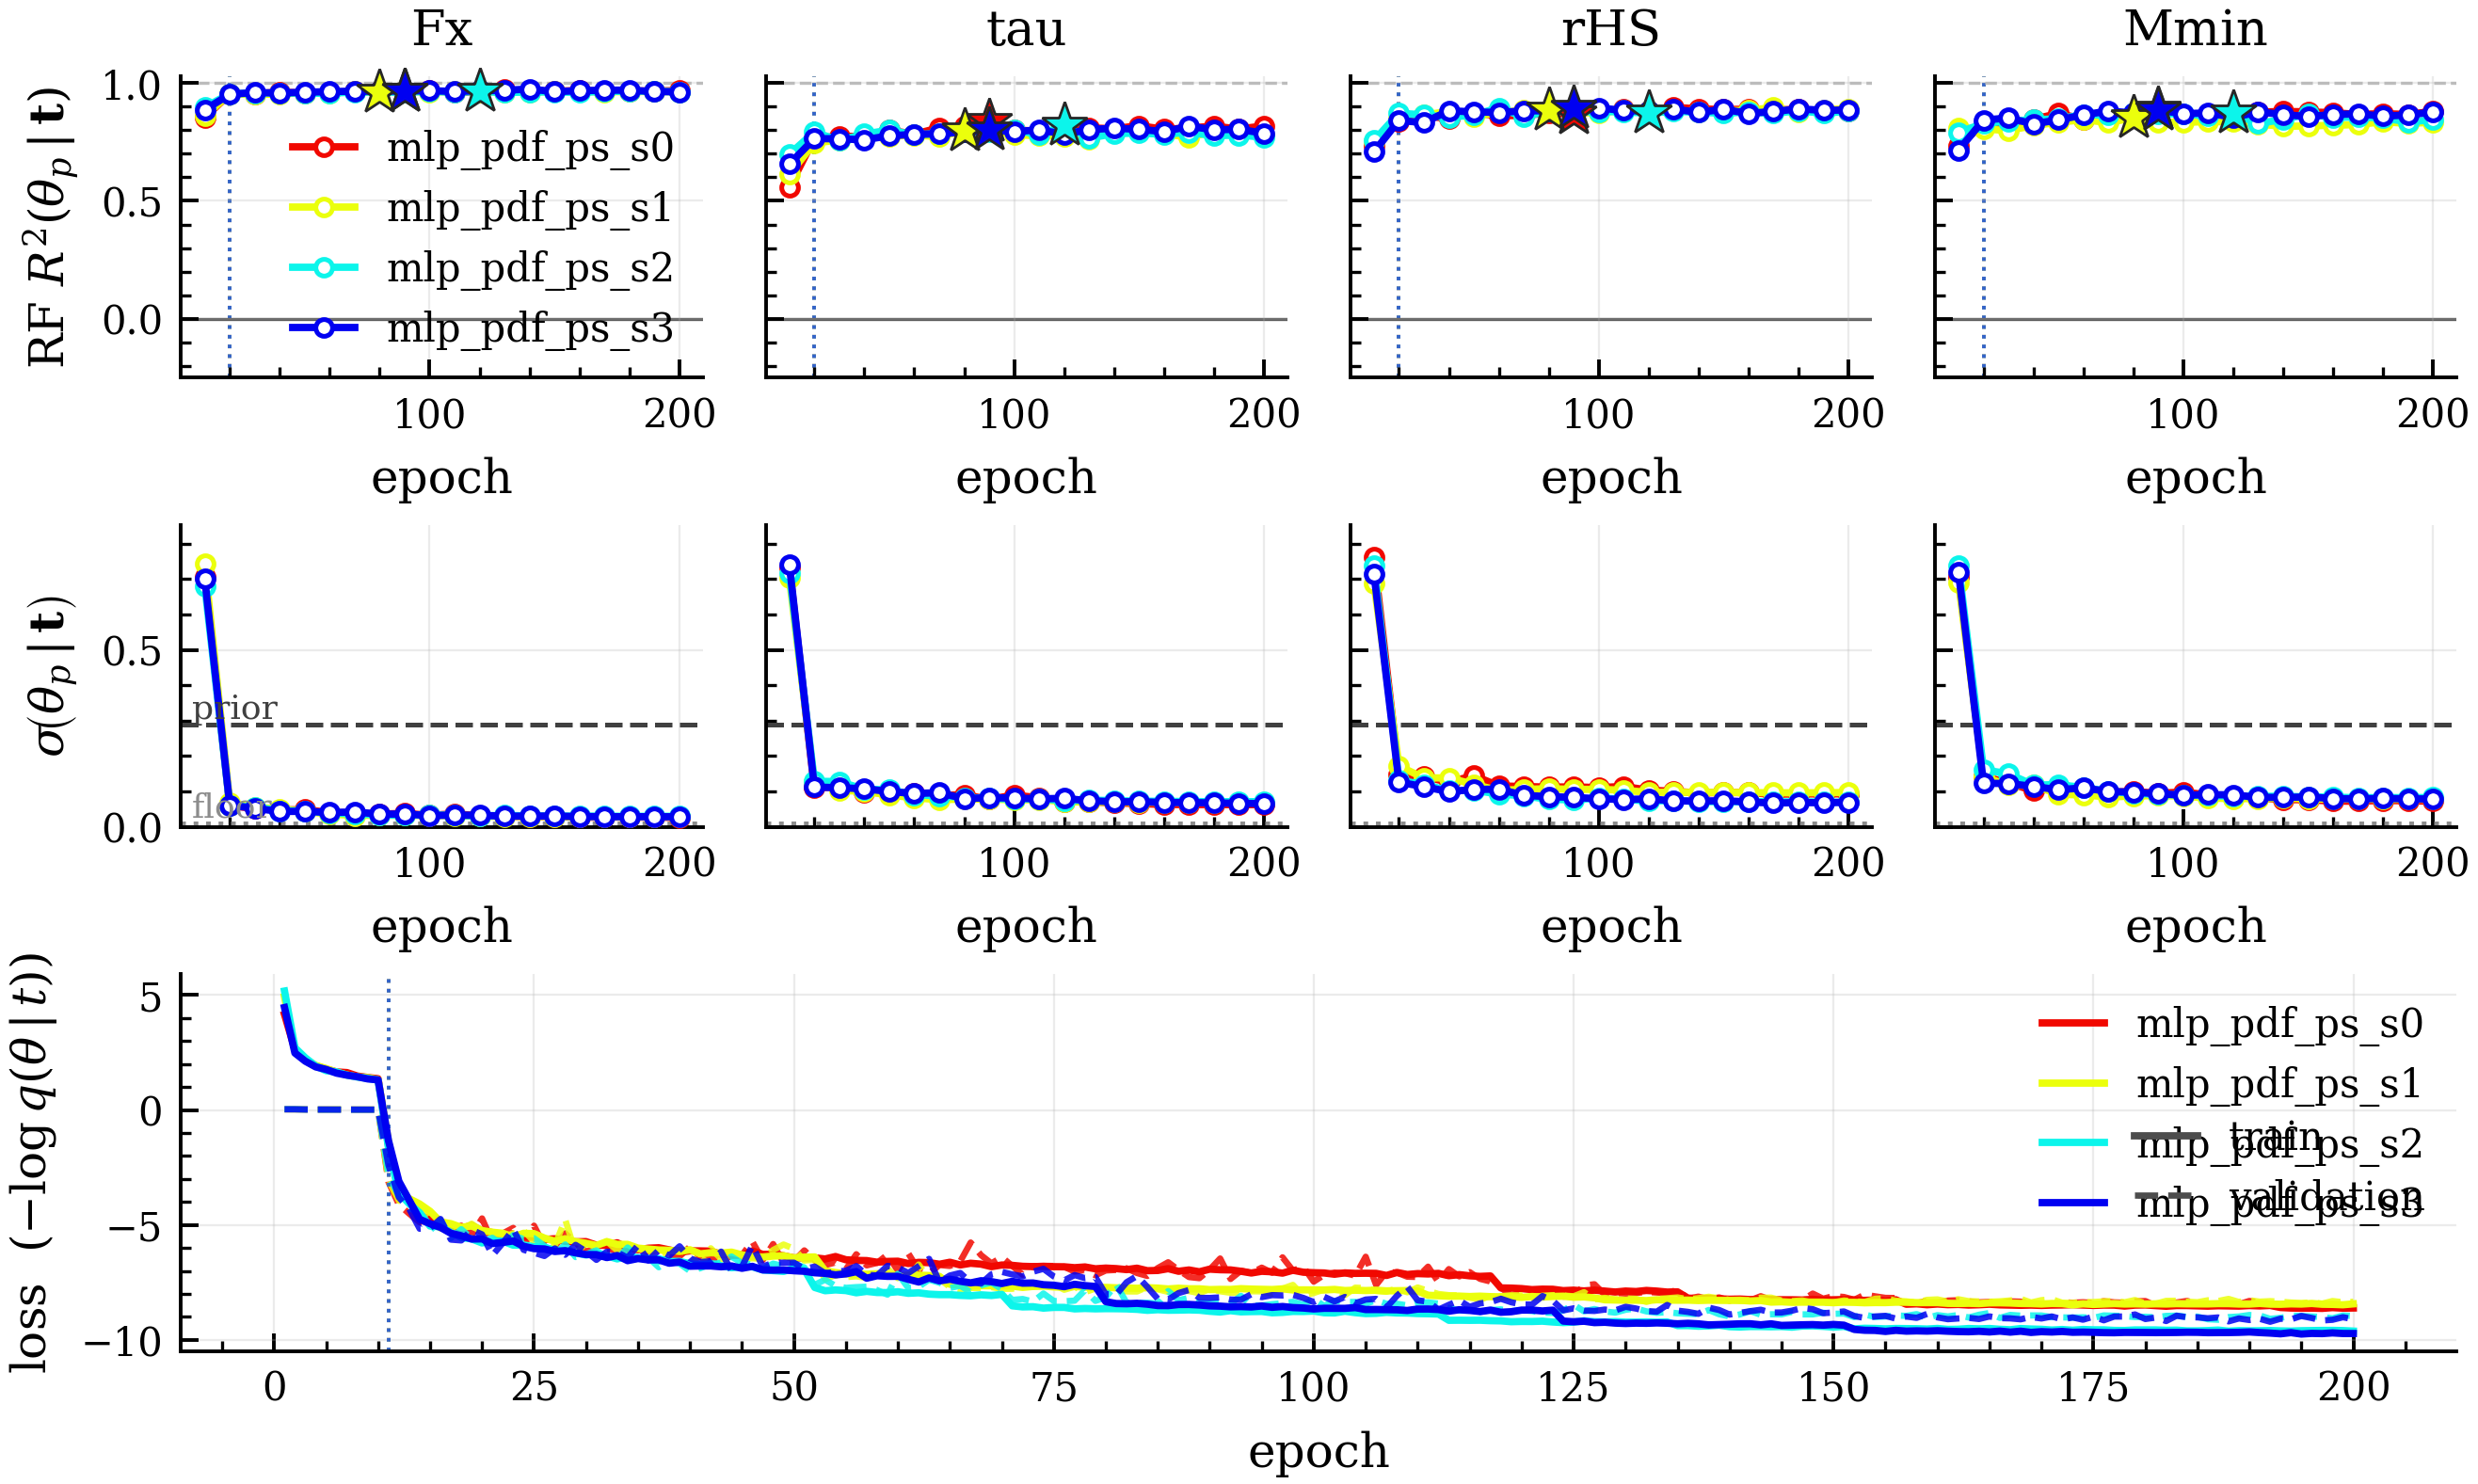

In [3]:
# Compressor training: RF-R^2 / conditional-sigma / loss, every (config, seed) overlaid.
arms = ' '.join(f'{cfg_tag(c)}_s{s}={nle_dir(c, s)}' for c in CONFIG for s in SEEDS)
fig  = DIR_COMP / f'{PATHDIR}_compressor.pdf'
sh(f'python tools/plot_training_compressor.py {arms} --names {NAMES} --out "{fig}" --png')
show(fig.with_suffix('.png'), width=1100)

## 3 · NLE training

$ python tools/plot_training_nle.py "configs_seeds/mlp_/arm_mlp_pdf_ps.yaml" --seeds 0 1 2 3 --models gmm nsf --out "notebooks/figs_mlp/nle/mlp_nle.png"
[arm_mlp_pdf_ps] discovered seeds=[0, 1, 2, 3]  with loss data=[0, 1, 2, 3]

[SUCCESS] wrote notebooks/figs_mlp/nle/mlp_nle.png


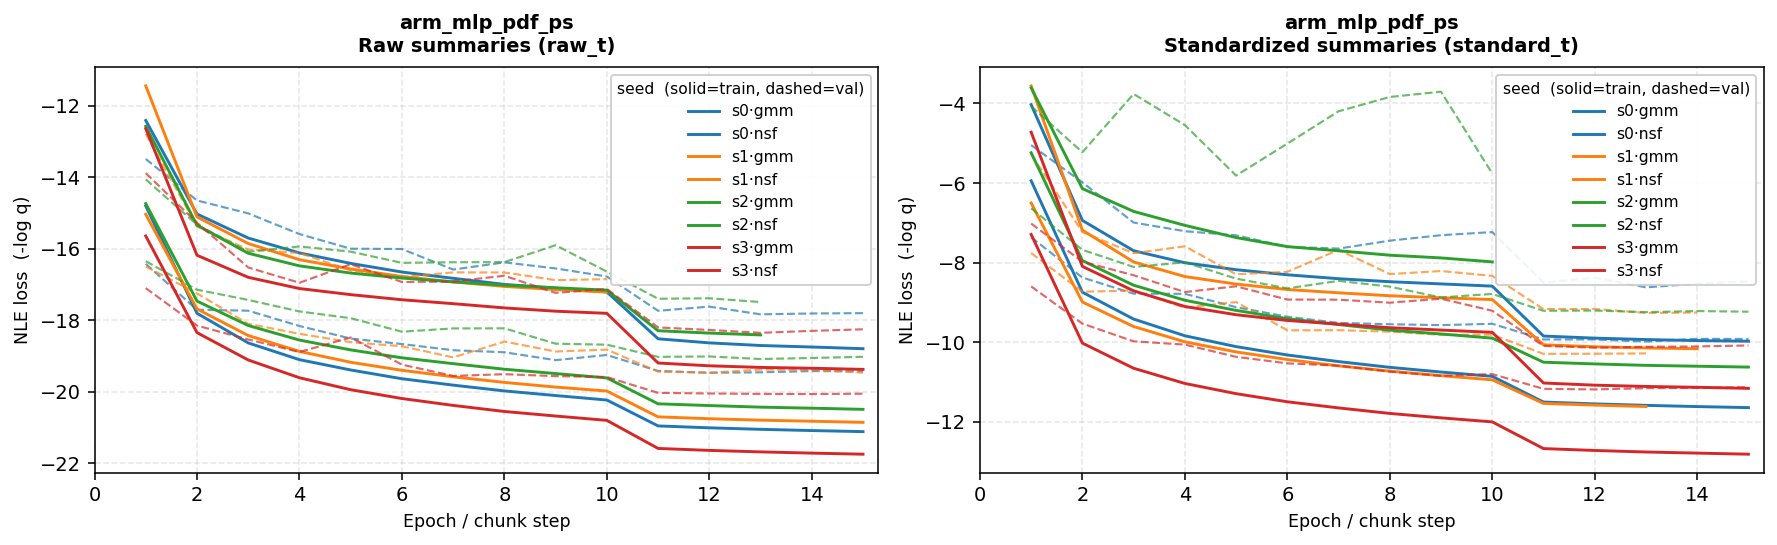

In [4]:
# NLE training: train (solid) / val (dashed) loss per family, all seeds overlaid.
seeds = ' '.join(map(str, SEEDS))
cfgs  = ' '.join(f'"{c}"' for c in CONFIG)
fig   = DIR_NLE / f'{PATHDIR}_nle.png'
sh(f'python tools/plot_training_nle.py {cfgs} --seeds {seeds} --models {FAMILY} --out "{fig}"')
show(fig, width=1000)

In [ ]:
#seed 0,1 is with the jitter on
bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 123
bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=1 "gmm nsf" "std raw" 123

In [ ]:
#seed 0,1 is with the jitter off
bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=2 "gmm nsf" "std raw" 123
bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=3 "gmm nsf" "std raw" 123

In [6]:
!python check_nle.py /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps \
    --expected-chunks 15 \
    --seed-glob "seed_s[0123]" \
    --nle-subdirs nle/raw_t/gmm nle/raw_t/nsf nle/standard_t/gmm nle/standard_t/nsf


=== Root: pdf_ps ===
  seed_s0   | R_GMM:ok     | R_NSF:ok     | S_GMM:ok     | S_NSF:ok    
  seed_s1   | R_GMM:(NO_MOD) | R_NSF:ok     | S_GMM:(NO_MOD) | S_NSF:(NO_MOD)
  seed_s2   | R_GMM:(NO_MOD) | R_NSF:ok     | S_GMM:(NO_MOD) | S_NSF:ok    
  seed_s3   | R_GMM:ok     | R_NSF:ok     | S_GMM:ok     | S_NSF:ok    

  -> 2/4 seeds fully trained (all subdirs reached 15 chunks)

2 seed(s) need training to resume/finish.


In [29]:
!python check_chains.py /gscratch/ddehiwalage-don/sbi_master/mlp_/pdf_ps/ --expected 908 --seed-glob "seed_s[23]" \
#    --chain-subdirs chains/raw_t_gmm chae;ins/raw_t_nsf chains/standard_t_gmm chains/standard_t_nsf


=== Root: pdf_ps ===
  seed_s2   | R_GMM:(NO_DIR) | R_NSF:no(93) | S_GMM:(NO_DIR) | S_NSF:no(523)
  seed_s3   | R_GMM:ok     | R_NSF:ok     | S_GMM:ok     | S_NSF:ok    

  -> 1/2 seeds fully complete (all subdirs >= 908)

1 seed(s) need stage-3 (re)run.


In [13]:
#!bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_pdf_ps.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 3

config=configs_seeds/mlp_/arm_mlp_pdf_ps.yaml  arm(yaml)=mlp_/pdf_ps/seed  arm_type=mlp  stage1_script=slurm/stage1_mlp.sbatch
stages=3  stage1=skip  stage2=skip  stage3=yes
overrides: -o compressor.init_seed=0
grid: families=[gmm nsf]  scalings=[std raw]
batches: gmm=yaml maf=32 nsf=32

  gmm  std  stage2=skip       stage3=5370244    batch=yaml
  gmm  raw  stage2=skip       stage3=5370245    batch=yaml
  nsf  std  stage2=skip       stage3=5370246    batch=32
  nsf  raw  stage2=skip       stage3=5370247    batch=32

submitted grid of 4 family/scaling combinations.
monitor: squeue -u $USER

leaf dirs (no collisions):
  nle/standard_t/gmm   chains/standard_t_gmm
  nle/raw_t/gmm   chains/raw_t_gmm
  nle/standard_t/nsf   chains/standard_t_nsf
  nle/raw_t/nsf   chains/raw_t_nsf


### for PS only
1. seed0   dequant:
    2: {half: 0.1000}    # rHS,   6 grid points 
    3: {half: 0.0813}    # Mmin,  7 grid points

'bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_ps.yaml -o compressor.init_seed=0 "gmm nsf" "std raw" 123'

2. seed1 without dequant
bash submit_nle_grid.sh configs_seeds/mlp_/arm_mlp_ps.yaml -o compressor.init_seed=1 "gmm nsf" "std raw" 123

## 4 · SBC campaign

In [33]:
# SBC campaign (stage 4 / eval.py): rank histograms, coverage metrics, overlay corner.
# One --item per (config, family, scope); seeds averaged with --all-seeds.
items     = [f'{c}|{fam}|{sc}|{cfg_tag(c)} {fam}/{sc}'
             for c in CONFIG for fam in FAMILY.split() for sc in SCOPE.split()]
item_args = ' '.join(f'--item "{it}"' for it in items)
seeds     = ' '.join(map(str, SEEDS))
#sh(f'CUDA_VISIBLE_DEVICES="" python eval.py {item_args} --all-seeds --seeds {seeds} '
#   f'--dlogp 10 --corner-sim median --out "{DIR_SBC}"')
# Heavy campaign? submit instead of running inline:
!sbatch slurm/stage4_nb.sbatch raw {item_args} --all-seeds --seeds {seeds} --out {DIR_SBC}

Submitted batch job 5370489


In [ ]:
m = DIR_SBC / 'metrics.csv'
if m.exists(): display(pd.read_csv(m))
for pdf in sorted(glob.glob(str(DIR_SBC / '*.pdf'))):
    print(os.path.basename(pdf)); show(pdf, width=850)